# Python Notebook for Constructing Sensor Curves Figure

### Data-Generation

Signals are designed to mimic noisy, partially correlated sensors:

1. Each variable is a composite of randomized sine waves which themselves have randomized periods over short intervals, so every channel drifts over time.
2. All variables remain range bound to resemble physical measurements.
3. Only a small fraction of the total number of channels "R" drive the target; their time-shifted threshold crossings must all be satisfied to trigger an event.
4. Every example flattens (H+1) time steps for each sensor, yielding R x (H+1) features.

In [7]:
from typing import Dict, List, Tuple, Sequence, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties

BASE_FONT_SCALE = 1.2
TITLE_FONT_SCALE = 1.5

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid", context="notebook", font_scale=BASE_FONT_SCALE)
LEGEND_FONT_SIZE = plt.rcParams["font.size"]
TITLE_FONT_SIZE = FontProperties(size=plt.rcParamsDefault["axes.titlesize"]).get_size_in_points() * TITLE_FONT_SCALE


### Synthetic data generator

This function is produces the synthetic longitudinal dataset, train/test splits, and optional diagnostic payloads.

In [8]:
# Synthetic generator adapted from sensor_generate - commented.py
def generate_synthetic_dataset(
    N: int = 100,                                             # number of base random variables
    S: int = 40,                                              # number of superposed variables
    R: Sequence[int] = (5, 6, 9, 10, 15, 25, 30),             # 1-based indices of relevant superposed vars
    AB: Sequence[str] = ("a", "a", "b", "b", "a", "b", "n"),  # threshold modes for each relevant var
    gp: Sequence[int] = (1, 1, 1, 1, 1, 1, 1),                # or-clause grouping (1-based) - default is all AND
    n_cycles: int = 40,                                       # how many 0-to-pi sinusoid cycles per base signal
    H: int = 10,                                              # historical timesteps to capture
    rseed: int = 1234,                                        # RNG seed
    train_fr: float = 0.7,                                    # train/test split fraction
    disp: Sequence[int] = (                                   # time displacements (length S)
        0,  0,  0,  0, 10,  6,  0, 10,  1,  0,
        0,  0,  2,  0,  5,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  3,  0,  0,  0,  0,  7,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0
    ),
    thresh_a: float = 0.20,                                   # above threshold (fraction of range)
    thresh_b: float = 0.75,                                   # below threshold (fraction of range)
    return_extra: bool = False                                # optionally return debug structures

) -> Union[Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame],
           Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str, any]]]:
    """
    Generates synthetic data for experiments.

    Returns
    -------
    dset   : pd.DataFrame  full labelled set (chronologically sorted)
    train  : pd.DataFrame  training subset
    test   : pd.DataFrame  testing  subset (non-overlapping with train)

    If `return_extra=True`, the fourth return value is a dict containing
    intermediate objects (`SIG_SIN_RND`, `SIG_SUPPOS`, `time_steps`, etc.).
    This should only be needed for debugging.
    """
    # ------------------------------------------------------------------------------------------
    # 1) RNG setup and basic helpers
    # ------------------------------------------------------------------------------------------
    np.random.seed(rseed)

    # Helper as in R (keep the same convention): degrees â†’ radians.
    deg2rad = np.deg2rad

    # ------------------------------------------------------------------------------------------
    # 2) Build N random-frequency sinusoid vectors (SIG_SIN_RND)
    # ------------------------------------------------------------------------------------------
    # Each base vector is formed by concatenating `n_cycles` segments of sinusoids over 90..450 degrees,
    # sampled at a random integer step in [1,5].  Then we randomly clip 0..71 samples off the front
    # (phase jitter) and record the minimum length across all N vectors so we can equalize later.
    sig_sin_rnd: List[np.ndarray] = []
    nmin = np.inf                                         # shortest length seen

    for _ in range(N):
        cycles: List[np.ndarray] = []
        for __ in range(n_cycles):
            step = np.random.randint(1, 6)                # 1&5 (inclusive)
            seq_deg = np.arange(90, 450, step, dtype=float)
            cycles.append(np.sin(deg2rad(seq_deg)))
        vec = np.concatenate(cycles)

        # random phase clipping: drop 071 samples from the front
        clip_start = np.random.randint(0, 72)
        vec = vec[clip_start:]

        # keep track of the shortest vector (needed to align lengths for superposition)
        if vec.size < nmin:
            nmin = vec.size
        sig_sin_rnd.append(vec)

    # Equalize lengths and apply a small vertical shift in [0.01, 2.00] to each base vector.
    # Vertical shifts prevent degenerate cancellations when summing.
    for i, vec in enumerate(sig_sin_rnd):
        shift = np.random.randint(1, 201) / 100.0         # 0.01 & 2.00
        sig_sin_rnd[i] = vec[:nmin] + shift

    # ------------------------------------------------------------------------------------------
    # 3) Superpose into S aggregate variables (SIG_SUPPOS)
    # ------------------------------------------------------------------------------------------
    # For each of S variables, pick a random base curve and add `nfun` more random base curves,
    # then apply a random scale.  This yields richer, partially correlated channels.
    nfun = N // S + 1                                      # how many extra curves to add
    sig_sup: List[np.ndarray] = []

    for _ in range(S):
        base = sig_sin_rnd[np.random.randint(0, N)].copy()
        for __ in range(nfun):
            base += sig_sin_rnd[np.random.randint(0, N)]
        scale = (np.random.normal(loc=0.0, scale=0.05) + 0.02) * 100.0
        sig_sup.append(base * scale)

    sig_sup = np.array(sig_sup)      # shape (S, nmin)

    # ------------------------------------------------------------------------------------------
    # 4) Apply per-variable time displacements 
    # ------------------------------------------------------------------------------------------
    # The R script time-shifts certain signals. In this Python version, `SS` is a copy of `sig_sup`.
    # Below, the *labeling condition* itself is shifted forward (via `shift_forward_bool`) rather than
    # shifting the signal values used as features. This design avoids leakage from trivial copies of
    # the target into features when building windows, but is a conscious divergence from the R snippet
    # shown in the docstring block (kept as an inert string here).
    SS = sig_sup.copy()
    
    """
    disp = np.asarray(disp, dtype=int)
    for idx_one_based in R:  # R indices are 1-based
        idx = idx_one_based - 1
        d = disp[idx]
        if d > 0:
            shifted = np.empty_like(SS[idx])
            shifted[:d] = 0
            shifted[d:] = SS[idx, :-d]
            SS[idx] = shifted
    """
    
    # helper to shift a boolean vector forward by d steps
    def shift_forward_bool(mask: np.ndarray, d: int) -> np.ndarray:
        if d <= 0:
            return mask.astype(bool).copy()
        out = np.zeros_like(mask, dtype=bool)
        out[d:] = mask[:-d]
        return out
  
    # ------------------------------------------------------------------------------------------
    # 5) Build OR-of-ANDs mask of positive outcomes (logic gate)
    # ------------------------------------------------------------------------------------------
    # For each relevant series râˆˆR, compute a boolean condition by thresholding either above 'a',
    # below 'b', or between (a,b) depending on AB[i].  Then shift that *condition* by disp[r].
    # Within each group g (gp[i]), we AND the conditions (all must hold), and across groups we OR.
    # This builds an interpretable DNF-like target, which aligns with logic-parsing approaches to
    # longitudinal features highlighted in our BigData'22 paper.
    total_len = SS.shape[1]
    posg: Dict[int, np.ndarray] = {}
    limits: Dict[str, Tuple[float, float]] = {}
    
    for i, r_one in enumerate(R):
        idx = r_one - 1
        g = gp[i]
        if g not in posg:
            posg[g] = np.ones(total_len, dtype=bool)
    
        vec = sig_sup[idx]                      # <â€” unshifted baseline series (see note above)
        lo, hi = vec.min(), vec.max()
        #print(f" {idx}")
        d = int(disp[idx])
        name = f"V{r_one}TM{d}"
    
        if AB[i] == "a":
            thr = thresh_a * (hi - lo) + lo
            cond = vec > thr
            limits[name] = (thr, hi)
        elif AB[i] == "b":
            thr = thresh_b * (hi - lo) + lo
            cond = vec < thr
            limits[name] = (lo, thr)
        elif AB[i] == "n":
            thr_lo = thresh_a * (hi - lo) + lo
            thr_hi = thresh_b * (hi - lo) + lo
            cond = (vec > thr_lo) & (vec < thr_hi)
            limits[name] = (thr_lo, thr_hi)
        else:
            raise ValueError("AB entries must be 'a', 'b', or 'n'.")
    
        # Apply time displacement to the condition (not the raw series).
        posg[g] &= shift_forward_bool(cond, d)
    
    # OR across groups to get the final positive mask; also build a simple attribution bitmask.
    positive_mask = np.zeros(total_len, dtype=bool)
    attrib = np.zeros(total_len, dtype=int)
    for g, mask in posg.items():
        positive_mask |= mask
        attrib += mask.astype(int) * (2 ** (g - 1))

    time_steps = np.nonzero(positive_mask)[0]              # 0-based indices where the logic gate fires

    # ------------------------------------------------------------------------------------------
    # 6) Assemble labelled examples (historical windows of length H+1)
    # ------------------------------------------------------------------------------------------
    # For each time t, we pull a *contiguous* block [t-H, â€¦, t] from the SÃ—T matrix (SS),
    # flatten it in variable-major order so columns become V_iTM{lag}, and attach label INDC.
    # Naming convention: TMH, TM(H-1), â€¦, TM0 (TM = "time minus").
    def make_examples(indices: np.ndarray, label: bool) -> pd.DataFrame:
        records = []
        for t in indices:
            records.append(SS[:, t - H : t + 1].flatten(order="C"))  # (S*(H+1),)
        df = pd.DataFrame(
            np.vstack(records),
            columns=[f"V{vi+1}TM{H-j}"      # TMH, TM(H-1), â€¦, TM0
                     for vi in range(S)
                     for j in range(0, H+1)]
        )
        df["INDC"] = label
        df["X"] = indices + 1
        return df

    # Positive rows are those times where the gate fired and we have a full history (t > H).
    pos_idx = time_steps[time_steps > H]
    # Negatives are the complement (also requiring a full history).
    neg_idx = np.setdiff1d(np.arange(total_len), time_steps)
    neg_idx = neg_idx[neg_idx > H]

    pos_df = make_examples(pos_idx, True)
    neg_df = make_examples(neg_idx, False)

    # Concatenate and sort chronologically by X.
    dset = pd.concat([pos_df, neg_df], ignore_index=True).sort_values("X").reset_index(drop=True)

    # ------------------------------------------------------------------------------------------
    # 7) Train/test split
    # ------------------------------------------------------------------------------------------
    # The split is random without stratification here; prevalence control (if desired) is handled
    # upstream by _calibrate_thresholds_to_trfrac in the wrapper.
    n_train = int(round(train_fr * len(dset)))
    train_sel = np.random.choice(dset.index, size=n_train, replace=False)
    dset_train = dset.loc[train_sel].reset_index(drop=True)
    dset_test  = dset.drop(train_sel).reset_index(drop=True)

    if return_extra:
        # Optional debug payload to inspect the generative internals.
        extra = dict(
            SIG_SIN_RND=sig_sin_rnd,
            SIG_SUPPOS=sig_sup,
            SS=SS,
            time_steps=time_steps,
            limits=limits,
            attrib=attrib,
        )
        return dset, dset_train, dset_test, extra
    else:
        return dset, dset_train, dset_test

### Build the Dataset

We set the parameters and generate the synthetic data.

In [9]:
RESP_COL = 'INDC'
CASE1_DISP = (
    0, 0, 0, 0, 10, 0, 0, 10, 1, 0,
    0, 0, 2, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 3, 0, 0, 0, 0, 7,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0
)
CASE1_RELEVANT = (5, 8, 9, 10, 13, 25, 30)
CASE1_AB_MODES = ("a", "a", "b", "b", "a", "b", "n")
CASE1_PLOT_MAX_TIMESTEPS = 600  # Set to None to plot the full generated series
TRUE_FEATURES = ["V5TM10","V8TM10","V9TM1","V10TM0","V13TM2","V25TM3","V30TM7"]

CASE1_PARAMS = dict(
    N=100,
    S=40,
    R=CASE1_RELEVANT,
    AB=CASE1_AB_MODES,
    gp=(1, 1, 1, 1, 1, 1, 1),
    n_cycles=50,
    H=10,
    rseed=1234,
    train_fr=3437 / 4911,
    disp=CASE1_DISP,
    thresh_a=0.30,
    thresh_b=0.65,
)

dset, dset_train, dset_test, extra = generate_synthetic_dataset(**CASE1_PARAMS, return_extra=True)

def summarize_split(name: str, frame: pd.DataFrame) -> dict:
    positives = int(frame[RESP_COL].sum())
    total = len(frame)
    return {
        "Split": name,
        "Rows": total,
        "Positives": positives,
        "Positive %": positives / total,
    }

summary = pd.DataFrame([
    summarize_split("Full", dset),
    summarize_split("Train", dset_train),
    summarize_split("Test", dset_test),
])
display(summary)

metrics_records: List[dict] = []

def add_metrics(model: str, view: str, auc_tr: float, auc_te: float,
                f1_tr: np.ndarray, f1_te: np.ndarray, notes: str = ""):
    metrics_records.append(
        {
            "Model": model,
            "View": view,
            "Train AUC": auc_tr,
            "Test AUC": auc_te,
            "Train max F1": float(np.nanmax(f1_tr)),
            "Test max F1": float(np.nanmax(f1_te)),
            "Notes": notes,
        }
    )

,Split,Rows,Positives,Positive %
0,Full,6551,1044,0.159365
1,Train,4585,744,0.162268
2,Test,1966,300,0.152594


### Peek at the features that actually drive the label

In [10]:
preview_cols = TRUE_FEATURES + ["INDC", "X"]
display(dset[preview_cols].head())

,V5TM10,V8TM10,V9TM1,V10TM0,V13TM2,V25TM3,V30TM7,INDC,X
0,19.586976,14.064360,4.144405,2.135108,8.358669,26.792449,10.489732,False,12
1,19.081595,13.857113,4.151671,2.072954,7.249801,26.201549,10.074240,False,13
2,18.578717,13.650093,4.157563,2.013071,6.235751,25.627593,9.667857,False,14
3,18.080735,13.444039,4.161621,1.955842,5.319576,25.075457,9.271813,False,15
4,17.589965,13.239669,4.163394,1.901632,4.503686,24.549844,8.887294,False,16


### Relevant sensor curves

Each subplot shows one of the seven informative channels with the exact time steps
that satisfy the Case 1 logic gate highlighted in red.

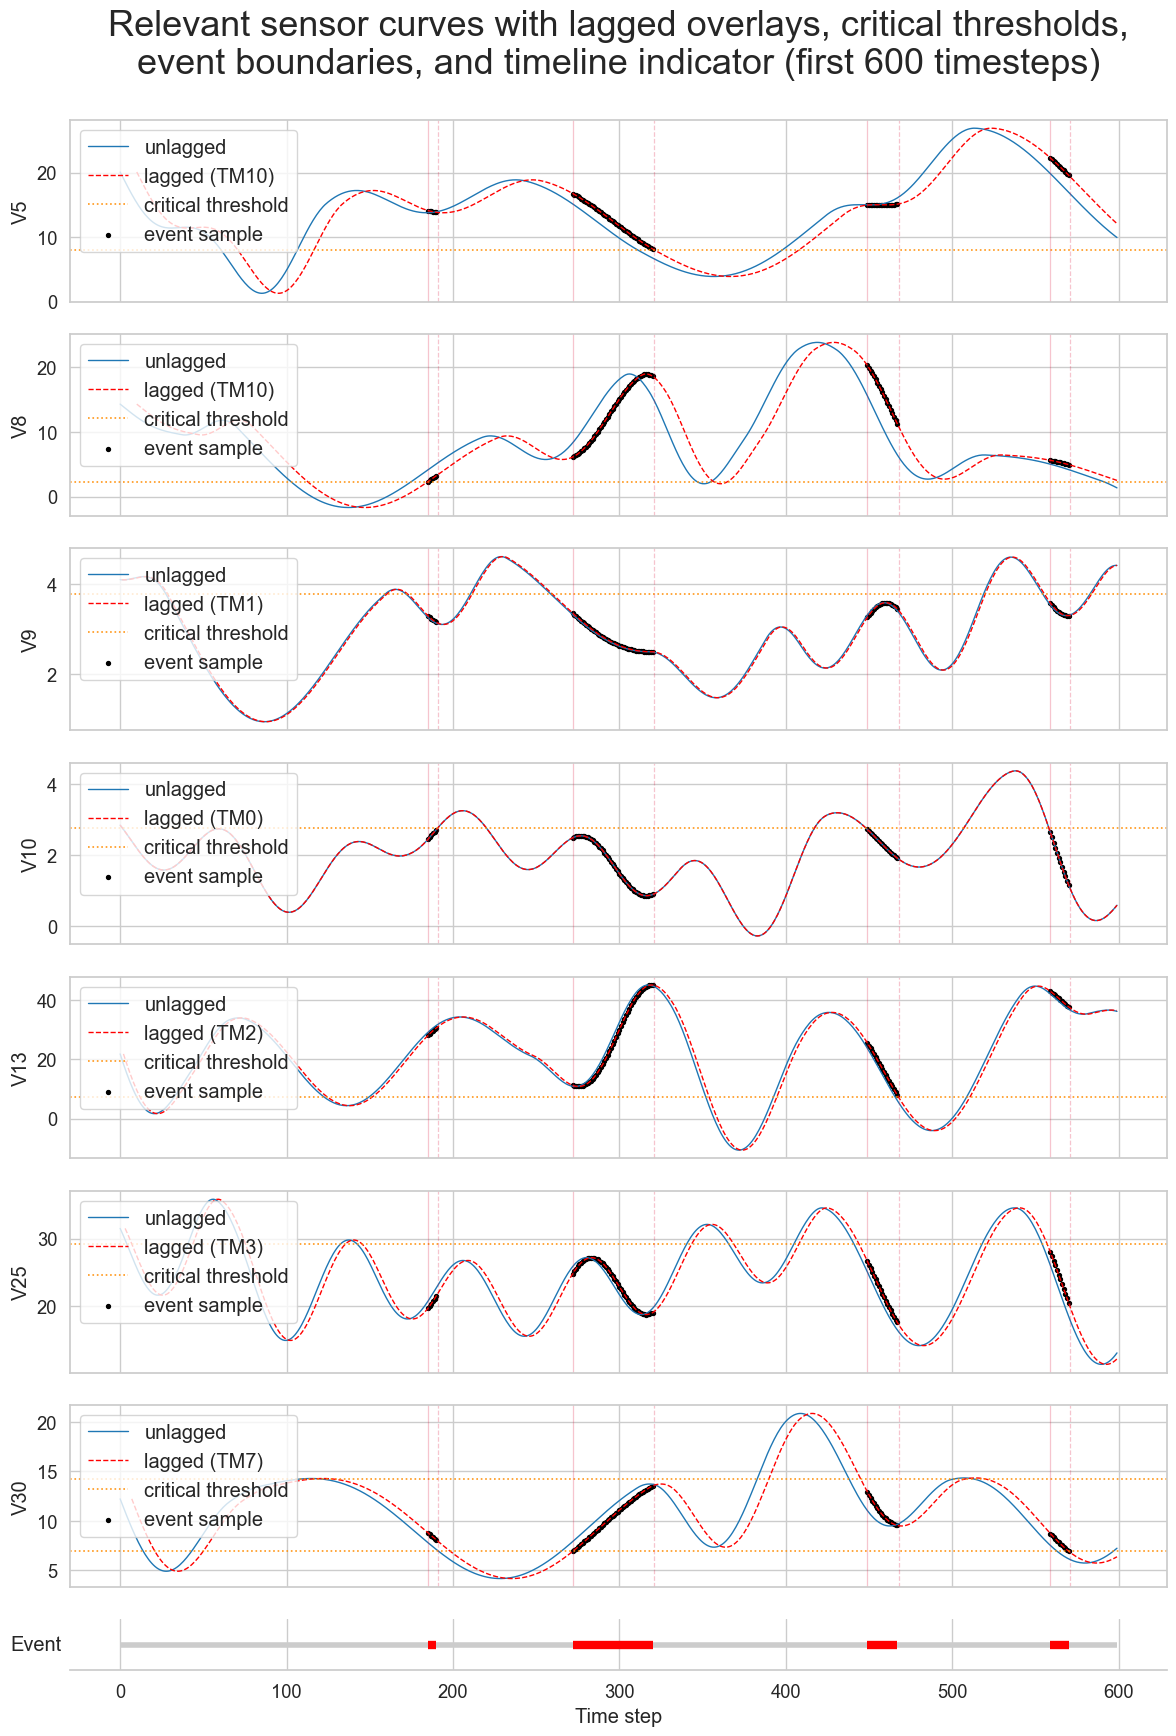

In [11]:
sig_sup = np.asarray(extra["SIG_SUPPOS"])
time_steps = np.asarray(extra["time_steps"], dtype=int)
disp = np.asarray(CASE1_DISP, dtype=int)
limits = extra.get("limits", {})
ab_mode_by_var = {r: m for r, m in zip(CASE1_RELEVANT, CASE1_AB_MODES)}
plot_max = CASE1_PLOT_MAX_TIMESTEPS
if plot_max is None:
    n_plot = sig_sup.shape[1]
else:
    n_plot = max(1, min(int(plot_max), sig_sup.shape[1]))

def lag_forward(series: np.ndarray, d: int) -> np.ndarray:
    out = np.full(series.shape, np.nan, dtype=float)
    if d <= 0:
        out[:] = series
    else:
        out[d:] = series[:-d]
    return out

hits = time_steps[(time_steps >= 0) & (time_steps < n_plot)]
event_mask = np.zeros(n_plot, dtype=bool)
event_mask[hits] = True
edge = np.diff(np.r_[0, event_mask.astype(int), 0])
event_starts = np.where(edge == 1)[0]
event_ends = np.where(edge == -1)[0] - 1

fig, axes = plt.subplots(
    len(CASE1_RELEVANT) + 1,
    1,
    figsize=(12, 2.3 * len(CASE1_RELEVANT) + 1.5),
    sharex=True,
    gridspec_kw={"height_ratios": [1] * len(CASE1_RELEVANT) + [0.28]},
)
axes = np.atleast_1d(axes)
curve_axes = axes[:-1]
indicator_ax = axes[-1]

for ax, var_idx in zip(curve_axes, CASE1_RELEVANT):
    full_series = sig_sup[var_idx - 1]
    series = full_series[:n_plot]
    d = int(disp[var_idx - 1])
    feature_name = f"V{var_idx}TM{d}"
    lim = limits.get(feature_name)
    mode = ab_mode_by_var.get(var_idx)
    lagged = lag_forward(full_series, d)[:n_plot]
    ax.plot(series, color="tab:blue", linewidth=1, label="unlagged")
    ax.plot(lagged, color="red", linestyle="--", linewidth=1, label=f"lagged (TM{d})")
    if lim is not None:
        if mode == "a":
            thr_vals = [lim[0]]
        elif mode == "b":
            thr_vals = [lim[1]]
        elif mode == "n":
            thr_vals = [lim[0], lim[1]]
        else:
            thr_vals = []
        for k, thr in enumerate(thr_vals):
            ax.axhline(
                thr,
                color="darkorange",
                linestyle=":",
                linewidth=1.2,
                alpha=0.9,
                label="critical threshold" if k == 0 else None,
            )
    event_y = lagged[hits]
    valid_hits = ~np.isnan(event_y)
    ax.scatter(hits[valid_hits], event_y[valid_hits], color="black", s=8, label="event sample")
    for x0 in event_starts:
        ax.axvline(x0, color="crimson", alpha=0.25, linewidth=0.9)
    for x1 in event_ends + 1:
        ax.axvline(x1, color="crimson", alpha=0.25, linewidth=0.9, linestyle="--")
    ax.set_ylabel(f"V{var_idx}")
    ax.legend(loc="upper left", fontsize=LEGEND_FONT_SIZE)

indicator_ax.hlines(0, 0, max(n_plot - 1, 0), color="0.8", linewidth=4)
for start, end in zip(event_starts, event_ends):
    indicator_ax.hlines(0, start, end, color="red", linewidth=6)
indicator_ax.set_ylim(-1, 1)
indicator_ax.set_yticks([])
indicator_ax.set_ylabel("Event", rotation=0, labelpad=25, va="center")
indicator_ax.spines["left"].set_visible(False)
indicator_ax.spines["right"].set_visible(False)
indicator_ax.spines["top"].set_visible(False)

curve_axes[0].set_title(
    f"Relevant sensor curves with lagged overlays, critical thresholds,\nevent boundaries, and timeline indicator (first {n_plot} timesteps)\n",
    fontsize=TITLE_FONT_SIZE,
)
indicator_ax.set_xlabel("Time step")
plt.tight_layout()

In [12]:
from pathlib import Path

out_dir = Path("Figures")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "threshold_and_lag.pdf"
fig_to_save = fig if "fig" in globals() else plt.gcf()
fig_to_save.savefig(out_path, bbox_inches="tight")
print(f"Saved: {out_path.resolve()}")

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\threshold_and_lag.pdf
